# Proyecto Sprint 11

## Introducción 

Se realizará un análisis para una empresa emergente que vende productos alimenticios. Esta empresa requiere que se investige el comportamiento del usuario para la aplicación de la empresa.
Se realizará un estudio de embudo de ventas, seguido de una prueba AAB, se cuenta con 2 grupos de control y uno de prueba. Los grupos de control son 246 y 247 y el grupo de prueba es 248.
Al equipo de diseño le gustaría cambiar las fuentes de toda la aplicación, pero la gerencia teme que los usuarios y las usuarias piensen que el nuevo diseño es intimidante. Por ello, deciden tomar una decisión basada en los resultados de un test A/A/B.
El objetivo final es identificar que conjunto de fuentes produce mejores resultados. 

### Paso 1: Abrir el archivo de datos y leer la información general

In [1]:
#se importan las librerías a utilizar 
import pandas as pd
import numpy as np
import math as mth 
import matplotlib.pyplot as plt 
import scipy.stats as st 
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import seaborn as sns

In [8]:
#se lee el archivo 
logs = pd.read_csv ('logs_exp_us.csv', sep = "\t" )
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [9]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


### Paso 2. Preparar los datos para el análisis

In [10]:
#visualizar los eventos y cuantos registros hay por cada uno 
logs['EventName'].value_counts()

EventName
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: count, dtype: int64

In [13]:
#visualizar cuantos usuarios unicos hay 
len(logs['DeviceIDHash'].unique ())

7551

In [15]:
#visualizar las pruebas 
logs['ExpId'].value_counts ()

ExpId
248    85747
246    80304
247    78075
Name: count, dtype: int64

- Se va a cambiar el nombre de las columnas por nombres mas sensillos.
- se va a cambiar timesamp a formato fecha y agrear una columna para fecha y hora y otra solo fecha.
- Se va a cambiar los nombres de grupos de control a A1, A2 y B para manejo mas sencillo, agregando una nueva columna. 

In [16]:
#se cambia el nombre de las columnas 
logs.rename (columns = {'EventName': 'event', 
                        'DeviceIDHash': 'user', 
                        'EventTimestamp': 'timestamp', 
                        'ExpId': 'exp_id'}, inplace = True)
logs.head()


,event,user,timestamp,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [18]:
#se cambia timestamp a formato fecha 
logs['timestamp'] = pd.to_datetime(logs['timestamp'], unit= 's')
logs.head()

,event,user,timestamp,exp_id
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248


In [20]:
#se agrega la columna fecha sin hora 
logs['date'] = logs['timestamp'].dt.floor('d')
logs.sample(10)

,event,user,timestamp,exp_id,date
126940,OffersScreenAppear,617758068537391848,2019-08-04 13:56:18,247,2019-08-04
15629,MainScreenAppear,6884354012020551124,2019-08-01 11:10:18,248,2019-08-01
9272,MainScreenAppear,438566018419758396,2019-08-01 07:56:59,248,2019-08-01
192525,OffersScreenAppear,2080457149997549644,2019-08-06 11:52:51,247,2019-08-06
54892,PaymentScreenSuccessful,5274212389021166684,2019-08-02 11:47:04,248,2019-08-02
126660,PaymentScreenSuccessful,3610536745613892312,2019-08-04 13:49:28,248,2019-08-04
64208,MainScreenAppear,4368889797498266615,2019-08-02 15:51:42,246,2019-08-02
144105,MainScreenAppear,3674399407724551993,2019-08-05 05:46:49,248,2019-08-05
222032,CartScreenAppear,3288613003957669743,2019-08-07 09:35:17,246,2019-08-07
77405,CartScreenAppear,8149549601152365766,2019-08-03 05:56:02,248,2019-08-03


In [ ]:
#se crea una funcion y la nueva columna para nuevos nombres de exp_id para facil manejo 
def exp (x):
    if x == 246:
        return 'A1'
    elif x == 247: 
        return 'A2'
    else:
        return 'B'

logs ['group'] = logs['exp_id'].apply (exp)
logs.sample(10)

,event,user,timestamp,exp_id,date,group
207198,MainScreenAppear,1999749841187613342,2019-08-06 18:00:13,248,2019-08-06,B
154070,CartScreenAppear,1531475045777130682,2019-08-05 11:07:30,246,2019-08-05,A1
186603,CartScreenAppear,8494595990824157619,2019-08-06 08:53:51,246,2019-08-06,A1
11725,OffersScreenAppear,7757474936326240239,2019-08-01 09:14:31,247,2019-08-01,A2
84033,CartScreenAppear,7717097133758101868,2019-08-03 09:41:13,247,2019-08-03,A2
185660,OffersScreenAppear,4862703399128856200,2019-08-06 08:22:55,248,2019-08-06,B
110740,MainScreenAppear,1225191038684666184,2019-08-04 05:56:35,247,2019-08-04,A2
212575,MainScreenAppear,1975810526287593167,2019-08-06 21:48:49,246,2019-08-06,A1
96317,OffersScreenAppear,6022375714473447159,2019-08-03 14:50:30,248,2019-08-03,B
89008,PaymentScreenSuccessful,8173190940950873857,2019-08-03 11:42:01,246,2019-08-03,A1


In [42]:
#se extrae la hora entera 
logs ['hour'] = logs['timestamp'].dt.hour
logs.head(5)

,event,user,timestamp,exp_id,date,group,hour
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25,A1,4
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25,A1,11
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25,B,11
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25,B,11
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25,B,11


### Paso 3. Estudiar y comprobar los datos

##### 1. ¿Cuántos eventos hay en los registros?

In [ ]:
#se calcula la cantidad de eventos registrados 
events = len (logs)
print(f'{events:,} events')

244,126 events


In [ ]:
#e identifica los diferentes eventos que hay 
dif_events = logs['event'].unique()
dif_events

array(['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear',
       'OffersScreenAppear', 'Tutorial'], dtype=object)

##### 2. ¿Cuántos usuarios y usuarias hay en los registros?

In [28]:
#se calcula la cantidad de usuarios unicos entre todos los registros 
users = len(logs['user'].unique ())
print(f'{users:,} users')

7,551 users


##### 3. ¿Cuál es el promedio de eventos por usuario?

In [31]:
#se calcula el promedio de eventos por usuario 
events_per_users = events / users 
print(f'{events_per_users:.2f} events per users')

32.33 events per users


##### 4. ¿Qué periodo de tiempo cubren los datos? Encuentra la fecha máxima y mínima. Traza un histograma por fecha y hora. ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo? Los eventos más antiguos podrían terminar en los registros de algunos usuarios o usuarias por razones técnicas y esto podría sesgar el panorama general. Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior. ¿Qué periodo representan realmente los datos?

In [ ]:
logs['date'].describe()

count                           244126
mean     2019-08-03 21:33:08.209367296
min                2019-07-25 00:00:00
25%                2019-08-02 00:00:00
50%                2019-08-04 00:00:00
75%                2019-08-06 00:00:00
max                2019-08-07 00:00:00
Name: date, dtype: object

- el rango de fechas va desde el 25 de julio al 7 de agosto del 2019. 

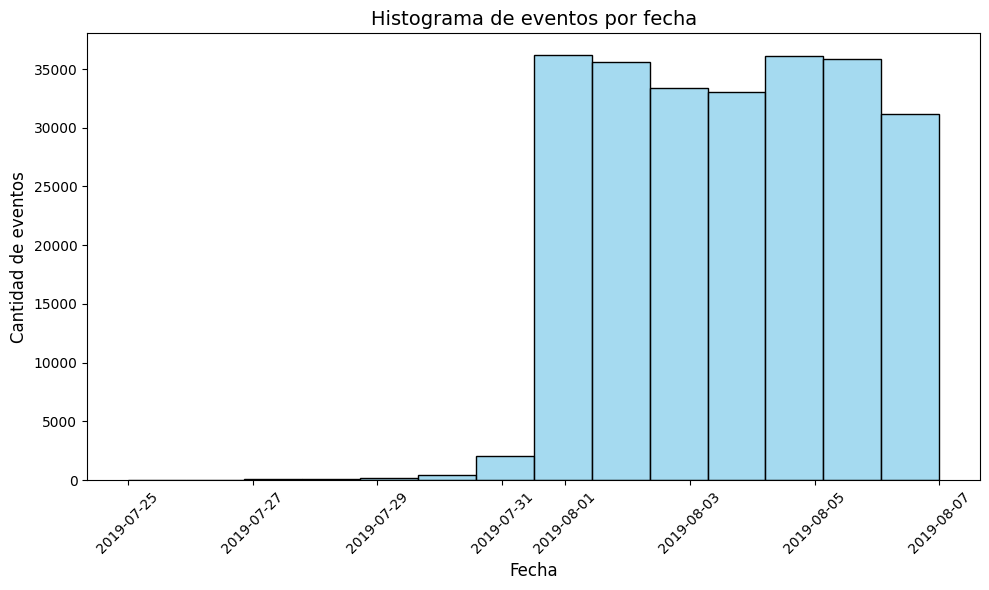

In [ ]:
#se crea un histograma por fecha 
plt.figure(figsize=(10, 6))
sns.histplot(data=logs, x='date', bins=14, color='skyblue', kde=False)

plt.title('Histograma de eventos por fecha', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de eventos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- Se puede ver que durante los primeros 7 días del experimentos no existen eventos regitrados por lo que se los puede eliminar para que no afecte los resultados. 

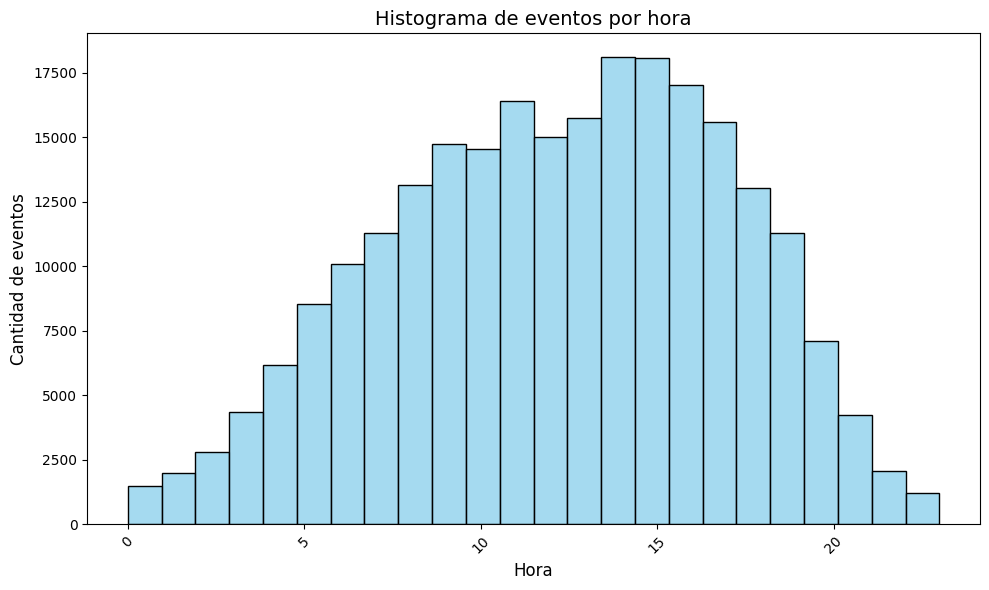

In [54]:
#se crea un histograma por hora 
plt.figure(figsize=(10, 6))
sns.histplot(data=logs, x='hour', bins=24, color='skyblue', kde=False)

plt.title('Histograma de eventos por hora', fontsize=14)
plt.xlabel('Hora', fontsize=12)
plt.ylabel('Cantidad de eventos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- La mayor cantidad de eventos se registran durante horas laborales o de uso normal de un computador, lo cual tiene sentido.

In [55]:
#se filtran los datos solo para tener información desde la fecha donde se registran los eventos - 01-08-2019
logs = logs[logs['date'] >= '2019-08-01']

In [58]:
#se calcula la cantidad de eventos restantes 
events2 = len (logs)
print (f'{events:,} eventos completos')
print(f'{events2:,} eventos restantes')

244,126 eventos completos
241,298 eventos restantes


- Se perdieron muy pocos eventos, por lo que no se afecta al dataset.

In [59]:
#se calcula la cantidad de usuarios restantes 
users2 = len(logs['user'].unique ())
print (f'{users:,} usuarios completos')
print(f'{users2:,} userios restantes')

7,551 usuarios completos
7,534 userios restantes


- Se pierden apenas 17 usuarios por lo que no se afecta el dataset.

In [61]:
events_by_exp = logs.groupby("group").agg(events = ("event","count"))
events_by_exp["share"] = round(events_by_exp["events"]/events_by_exp["events"].sum()*100,1)
events_by_exp

,events,share
group,,
A1,79425,32.9
A2,77147,32.0
B,84726,35.1


- Se puede ver que la distribución de la cantidad de eventos por grupo esta pareja, por lo que no hay problema.

### Paso 4. Estudiar el embudo de eventos

##### 1. Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.

In [62]:
events_frec = logs['event'].value_counts().sort_values(ascending= False)
events_frec

event
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: count, dtype: int64

- El evento que más se repite es MainScreenAppear, seguido de OfferScreenAppear. El evento que menos se repite es Tutorial, tiene una frecuencia muy baja por lo que se lo podría no considerar para próximos análisis. 

##### 2. Encuentra la cantidad de usuarios y usuarias que realizaron cada una de estas acciones. Ordena los eventos por el número de usuarios y usuarias. Calcula la proporción de usuarios y usuarias que realizaron la acción al menos una vez.

In [82]:
#se calcula la cantidad de usuarios por evento
users_by_events = logs.groupby('event').agg (
    users = ('user','nunique')).sort_values(
        'users', ascending= False)
users_by_events

,users
event,
MainScreenAppear,7419
OffersScreenAppear,4593
CartScreenAppear,3734
PaymentScreenSuccessful,3539
Tutorial,840


In [90]:
#se calcula la proporción de usuarios que realizaron al menos una vez cada evento. 
user_max = users_by_events['users'].max()
users_by_events['conv_rate'] = round(100 * users_by_events['users'] / user_max, 1)
users_by_events

,users,conv_rate
event,,
MainScreenAppear,7419,100.0
OffersScreenAppear,4593,61.9
CartScreenAppear,3734,50.3
PaymentScreenSuccessful,3539,47.7
Tutorial,840,11.3


##### 3. ¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? No es necesario tenerlas en cuenta al calcular el embudo.

- Las acciones ocurrieron en el orden en el que se presenta anteriormente, desde que aparece la pantalla principal hasta la pantalla de pago completo. El tutorial, es la única acción que podría suceder en cualquier momento por lo que podría no entrar denro del embudo ya que no es necesario verlo para completar las siguientes acciones. 

##### 4. Utiliza el embudo de eventos para encontrar la proporción de usuarios y usuarias que pasan de una etapa a la siguiente. (Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B).

In [98]:
#se elimina la acción tutorial ya que no sirve para este análisis y se calcula las tasas de conversión entre eventos
users_throught_events = users_by_events.drop(index= 'Tutorial', columns= 'conv_rate')

users_throught_events['conversion_rate'] = round(users_throught_events['users'] /users_throught_events['users'].shift(1) * 100,1)
users_throught_events.fillna({'conversion_rate': 100}, inplace= True)
users_throught_events

,users,conversion_rate
event,,
MainScreenAppear,7419,100.0
OffersScreenAppear,4593,61.9
CartScreenAppear,3734,81.3
PaymentScreenSuccessful,3539,94.8


##### 5. ¿En qué etapa pierdes más usuarios y usuarias?

- En la etapa que más usuarios se pierden es OffersScreenAppear, el 61,9% de los usuarios que ingrean a la pantalla inicial pasan a la siguiente actividad. 

##### 6. ¿Qué porcentaje de usuarios y usuarias hace todo el viaje desde su primer evento hasta el pago?

In [102]:
#Se calcula la tasa de conversión total desde MainScreenAppear hasta PaymentScreenSuccessful 

first_event_users = users_throught_events['users'].iloc[0] 
last_event_users = users_throught_events['users'].iloc[-1]

conv_rate_total = (last_event_users / first_event_users ) * 100
print (f'Porcentaje de usuarios que realizan todo el viaje: {conv_rate_total:.1f}%')

Porcentaje de usuarios que realizan todo el viaje: 47.7%


### Paso 5. Estudiar los resultados del experimento

##### 1. ¿Cuántos usuarios y usuarias hay en cada grupo?

In [131]:
#se calcula la cantidad de usuarios únicos en cada grupo 
users_by_group = logs.groupby('group').agg(users = ('user', 'nunique'))
users_by_group

,users
group,
A1,2484
A2,2513
B,2537


##### 2. Tenemos dos grupos de control en el test A/A, donde comprobamos nuestros mecanismos y cálculos. Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247.

In [ ]:
#se calcula la taza de conversión para el grupo A1
GroupA1 = logs.query("group == 'A1'").pivot_table(index = 'event', values = 'user', 
                                           aggfunc = 'nunique').sort_values ('user', ascending = False).drop(
                                               index = 'Tutorial')
n_A1 = GroupA1['user'].max()
GroupA1['conv_A1'] = (GroupA1['user']/ n_A1)*100
GroupA1.drop (columns = 'user', inplace = True)
GroupA1

,conv_A1
event,
MainScreenAppear,100.000000
OffersScreenAppear,62.938776
CartScreenAppear,51.673469
PaymentScreenSuccessful,48.979592


In [130]:
#se calcula la taza de conversión para el grupo A2
GroupA2 = logs.query("group == 'A2'").pivot_table(index = 'event', values = 'user', 
                                           aggfunc = 'nunique').sort_values ('user', ascending = False).drop(
                                               index = 'Tutorial')
n_A2 = GroupA2['user'].max()
GroupA2['conv_A2'] = (GroupA2['user']/ n_A2)*100
GroupA2.drop (columns = 'user', inplace = True)
GroupA2

,conv_A2
event,
MainScreenAppear,100.000000
OffersScreenAppear,61.389338
CartScreenAppear,50.000000
PaymentScreenSuccessful,46.768982


In [126]:
#se calcula la taza de conversión para el grupo B
GroupB = logs.query("group == 'B'").pivot_table(index = 'event', values = 'user', 
                                           aggfunc = 'nunique').sort_values ('user', ascending = False).drop(
                                               index = 'Tutorial')
n_B = GroupB['user'].max()
GroupB['conv_B'] = (GroupB['user']/ n_B)*100
GroupB.drop (columns = 'user', inplace = True)
GroupB

,conv_B
event,
MainScreenAppear,100.000000
OffersScreenAppear,61.411953
CartScreenAppear,49.338147
PaymentScreenSuccessful,47.372643


In [ ]:
#se juntas las 3 tablas creadas 
conversion = GroupA1.merge (GroupA2, on = 'event').merge (GroupB, on = 'event')
conversion

,conv_A1,conv_A2,conv_B
event,,,
MainScreenAppear,100.000000,100.000000,100.000000
OffersScreenAppear,62.938776,61.389338,61.411953
CartScreenAppear,51.673469,50.000000,49.338147
PaymentScreenSuccessful,48.979592,46.768982,47.372643


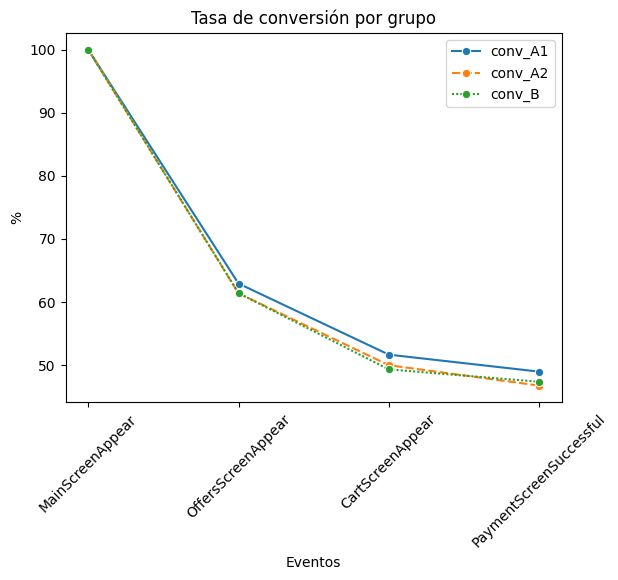

In [128]:
#se visualiza las diferentes tasas de conversión 
sns.lineplot(data = conversion, marker = 'o')
plt.title ('Tasa de conversión por grupo')
plt.xlabel ('Eventos')
plt.ylabel ('%')
plt.xticks (rotation = 45)
plt.show()

- Se puede ver que las conversiones para todos los grupos por evento son bastante similares, por lo que se debe realizar una prueba de hipótesis para comprobar si existe diferencia significativa. 

H0 = Las tasas de conversión entre los grupos A1 y A2 son iguales 

Ha = Las tasas de conversión entre los grupos A1 y A2 son diferentes 

In [139]:
#se crea una lista con el # total de usuarios en cada grupo 
n = pd.Series([n_A1,n_A2,n_B],index=["A1","A2","B"])
n

A1    2450
A2    2476
B     2493
dtype: int64

- Estos valore se reducen minimamente debido a que no se esta considerando el evento Tutorial 

In [140]:
conversion

,conv_A1,conv_A2,conv_B
event,,,
MainScreenAppear,100.000000,100.000000,100.000000
OffersScreenAppear,62.938776,61.389338,61.411953
CartScreenAppear,51.673469,50.000000,49.338147
PaymentScreenSuccessful,48.979592,46.768982,47.372643


In [145]:
#se calcula si existe diferencia significativa entre los 2 grupos de control 
#se toma como casos de éxito para cada grupo las tasas de conversión de los usuarios que llegaron al último paso
alpha = 0.05

conv_A1 = conversion['conv_A1'].iloc [-1] / 100  
conv_A2 = conversion['conv_A2'].iloc [-1] / 100  

suc_A1 = int (conv_A1 * n['A1'])
suc_A2 = int (conv_A2 * n['A2'])

suc = [suc_A1, suc_A2]
obs = [n['A1'], n['A2']]

z_stat, pval = proportions_ztest(
    count = suc, 
    nobs=obs, 
    alternative="two-sided")

print('Valor p:', pval)

if pval > alpha:
    print("No se rechaza H0: Las tasas de conversión son iguales")
else:
    print("Se rechaza la H0: existe diferencias significativas entre las tasas de conversión del grupo de control A1 con A2")

Valor p: 0.12044299485641764
No se rechaza H0: Las tasas de conversión son iguales


- Al no exitir una diferencia siginificativa, se dice que la prueba funciona correctamente y los datos están distribuidos de manera correcta. 

##### 3. Selecciona el evento más popular. En cada uno de los grupos de control, encuentra la cantidad de usuarios y usuarias que realizaron esta acción. Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa. Repite el procedimiento para todos los demás eventos (ahorrarás tiempo si creas una función especial para esta prueba). ¿Puedes confirmar que los grupos se dividieron correctamente?

- Se calculará desde el evento OffersScreenAppear ya que para el primer evento MainScreenAppear todos los grupos tienen la misma tasa de conversión del 100%

In [162]:
#Se crea una función para generalizar este proceso
def prueba_ab (e, g1, g2, alpha=0.05):

    #Muestra 1
    conv_1 = conversion.loc[e, f'conv_{g1}']/100
    suc_1 = int(conv_1*n[g1])
    suc_1

    #Muestra 2
    conv_2 = conversion.loc[e,f'conv_{g2}']/100
    suc_2 = int(conv_2*n[g2])
    suc_2

    suc = [suc_1,suc_2]
    obs = [n[g1],n[g2]]

    z_stat, pval = proportions_ztest(
        count = suc, 
        nobs=obs, 
        alternative="two-sided"
    )

    print('Valor p:', pval)


    if pval > alpha:
        print("No se rechaza H0: Las tasas de conversión son iguales")
    else:
        print("Se rechaza H0: Las tasas de conversión de control entre los 2 grupos tienen diferencias significativas")

    return pval

In [163]:
#se llama a la funcion para cada evento para comprobar si en algun evento existen diferencias entre A1 y A2
A1_A2 = []
for event in conversion.index[1:]:
    print(f'EVENTO: {event}')
    print('================')
    A1_A2.append(prueba_ab(event,"A1","A2"))
    print("\n")

EVENTO: OffersScreenAppear
Valor p: 0.2500499425807663
No se rechaza H0: Las tasas de conversión son iguales


EVENTO: CartScreenAppear
Valor p: 0.24012327015939383
No se rechaza H0: Las tasas de conversión son iguales


EVENTO: PaymentScreenSuccessful
Valor p: 0.12044299485641764
No se rechaza H0: Las tasas de conversión son iguales




- Se puede confirmar el mismo resultado obtenido anteriormente. Los grupos de control fueron divididos correctamente ya que no existe diferencias en las tasas de conversión para ningun evento entre los grupos A1 y A2. 

##### 4. Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?

In [164]:
#comprobar si existe diferencia entre A1 y B 
A1_B = []
for event in conversion.index[1:]:
    print(f'EVENTO: {event}')
    print('================')
    A1_A2.append(prueba_ab(event,"A1","B"))
    print("\n")

EVENTO: OffersScreenAppear
Valor p: 0.2684281587249231
No se rechaza H0: Las tasas de conversión son iguales


EVENTO: CartScreenAppear
Valor p: 0.10061042700489921
No se rechaza H0: Las tasas de conversión son iguales


EVENTO: PaymentScreenSuccessful
Valor p: 0.2582638437556217
No se rechaza H0: Las tasas de conversión son iguales




In [165]:
#comprobar si existe diferencia entre A2 y B 
A2_B = []
for event in conversion.index[1:]:
    print(f'EVENTO: {event}')
    print('================')
    A1_A2.append(prueba_ab(event,"A2","B"))
    print("\n")

EVENTO: OffersScreenAppear
Valor p: 0.9636220610086361
No se rechaza H0: Las tasas de conversión son iguales


EVENTO: CartScreenAppear
Valor p: 0.6408180183192491
No se rechaza H0: Las tasas de conversión son iguales


EVENTO: PaymentScreenSuccessful
Valor p: 0.6699208079332859
No se rechaza H0: Las tasas de conversión son iguales




### Conlcusiones 

- El periodo de tiempo con el que se trabajó es la segunda semana del experimento ya que la primera no se registraba ningún movimiento.  
- Una vez realizado los análisis de embudo de eventos se encontró que la mayor cantidad de usuarios se pierden al pasar de la pag principal a la oferta. La cantidad de usuarios que completan todo y pasan por todas las actividades es el 47.7% el cual se podría decir que es un buen resultado. 
- La prueba AA nos confirma que los grupos fueron distribuidos correctamente y que cualquier tipo e alteración intoriducida sería de manera natural. 
- Las pruebas de hipótesis para la prueba AB nos dicen que no existe una diferencia significativa en las tasas de conversión entre las fuentes actuales y las fuentes modificadas, por lo que podrín hacer el cambio sin problema. Sin embargo, podría existir un factor externo no controlado que podría estar reduciendo las tasas de conversión del grupo A2 y B minimamente. 